<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo3_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [3]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
def train_yolo():
    model = YOLO('yolov3u.pt')
    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train",
        name="yolov3",
        save=True,
        save_period=5,
        val=True
    )
    return model, results

In [15]:
def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")


def test_single_image(model_path, image_path):
    model = YOLO(model_path)

    # Tahmin
    results = model(image_path)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti - {len(results[0].boxes)} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.2f}")

In [16]:
def main():
    print("1. Model eğitimi başlatılıyor...")
    model, results = train_yolo()

    print("\n2. CSV'den metrikler okunuyor...")
    df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/results.csv')

    # Görselleştir
    print("\n3. Sonuçlar görselleştiriliyor...")
    visualize_results(df)

    # Test et
    print("\n4. Tek görsel test ediliyor...")
    test_single_image('best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')

In [17]:
if __name__ == "__main__":
    main()

1. Model eğitimi başlatılıyor...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov3u.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov32, nbs=64, nms=False, opset=None, optimize=False, opti

train: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/train.cache... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.9±0.3 ms, read: 8.7±5.5 MB/s, size: 40.4 KB)


val: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/val.cache... 71 images, 0 backgrounds, 0 corrupt: 100%|██████████| 71/71 [00:00<?, ?it/s]


...

                   all         71        925      0.979      0.977      0.989      0.857



50 epochs completed in 0.159 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/weights/last.pt, 207.7MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/weights/best.pt, 207.7MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv3 summary (fused): 96 layers, 103,667,324 parameters, 0 gradients, 282.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.56it/s]


                   all         71        925      0.981      0.976      0.989      0.869
                   car         71        912      0.961      0.969      0.984      0.776
                   bus         13         13          1      0.984      0.995      0.963
Speed: 0.1ms preprocess, 2.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32

2. CSV'den metrikler okunuyor...


FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'


2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         0.84321         0.39780         0.78066    0.98114  0.97051   
41     42         0.82371         0.37735         0.78577    0.98935  0.97194   
42     43         0.78948         0.36445         0.78097    0.98612  0.97795   
43     44         0.77645         0.35877         0.77490    0.98240  0.98048   
44     45         0.75228         0.34619         0.78459    0.98543  0.97896   
45     46         0.74401         0.34445         0.78440    0.98580  0.97671   
46     47         0.73279         0.34322         0.78425    0.97928  0.97951   
47     48         0.68731         0.32722         0.77600    0.97998  0.97630   
48     49         0.69227         0.32872         0.77351    0.98066  0.97634   
49     50         0.67451         0.32290         0.77439    0.97886  0.97719   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

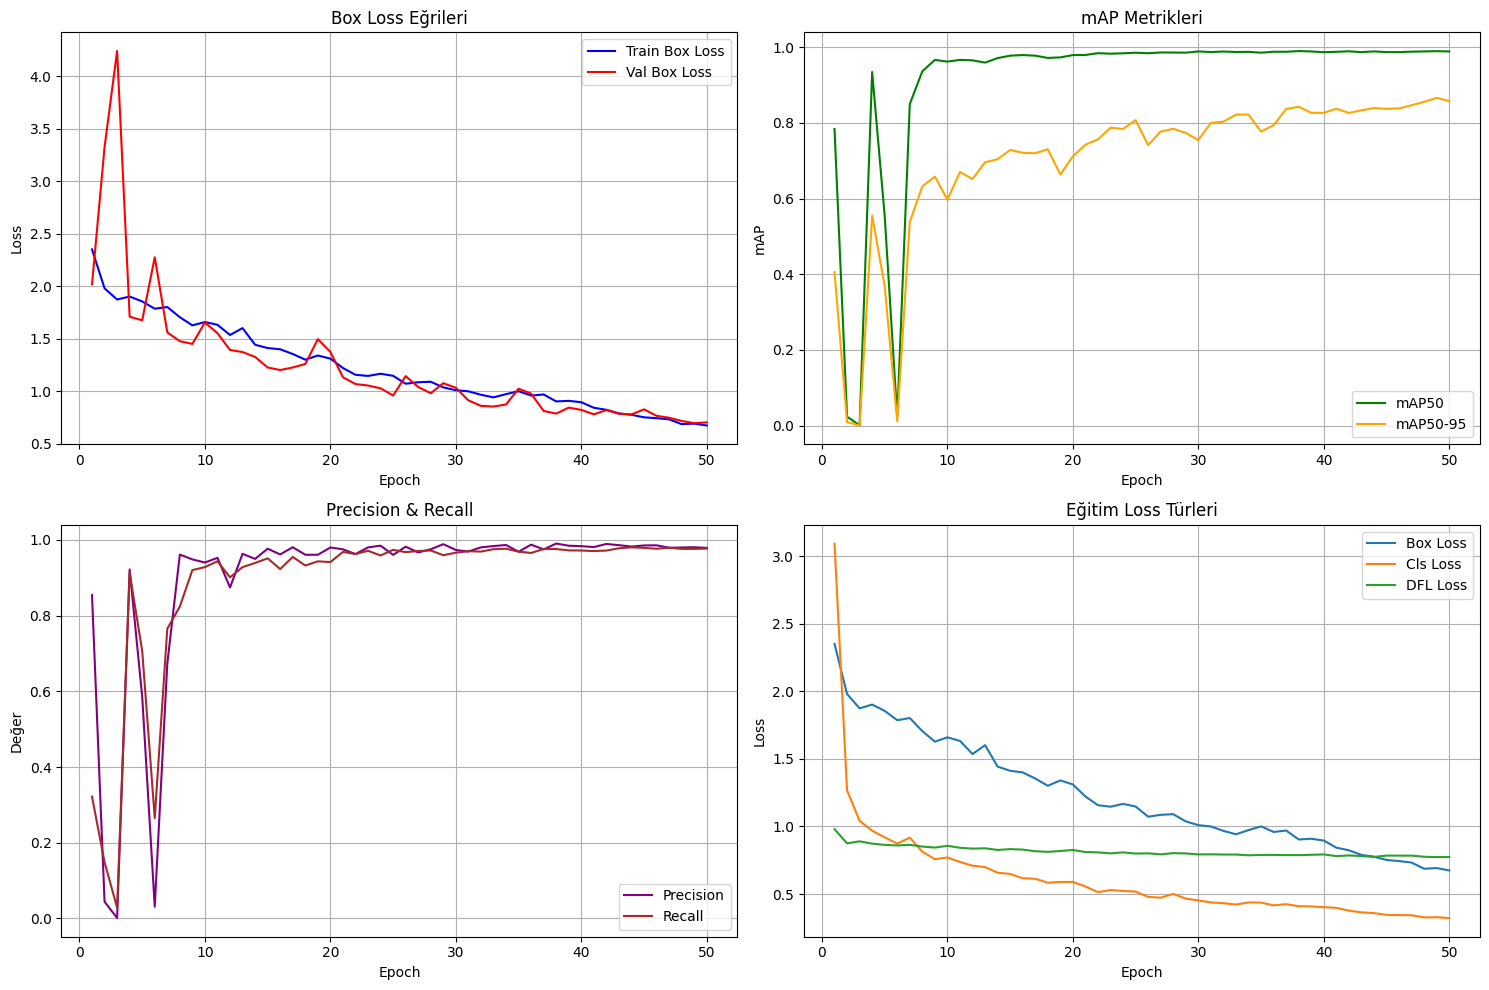


Final Epoch (50) Sonuçları:
mAP50: 0.9886
mAP50-95: 0.8575
Precision: 0.9789
Recall: 0.9772

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 8 cars, 55.3ms
Speed: 2.4ms preprocess, 55.3ms inference, 2.9ms postprocess per image at shape (1, 3, 352, 640)


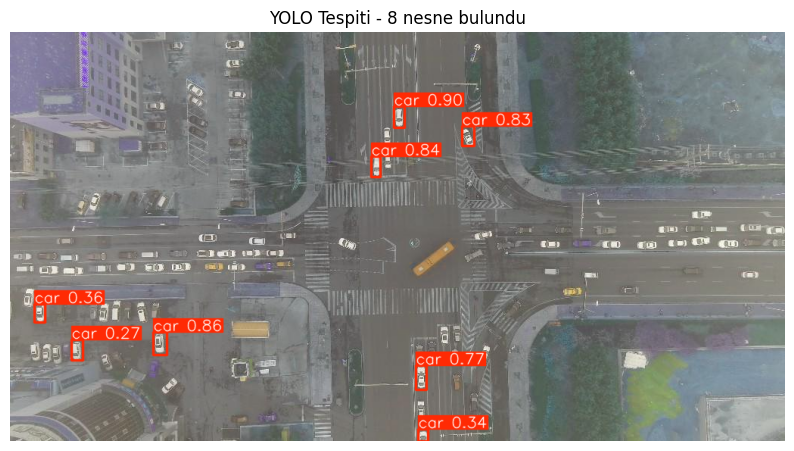

Nesne 1: Sınıf 0, Güven: 0.90
Nesne 2: Sınıf 0, Güven: 0.86
Nesne 3: Sınıf 0, Güven: 0.84
Nesne 4: Sınıf 0, Güven: 0.83
Nesne 5: Sınıf 0, Güven: 0.77
Nesne 6: Sınıf 0, Güven: 0.36
Nesne 7: Sınıf 0, Güven: 0.34
Nesne 8: Sınıf 0, Güven: 0.27


In [20]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo3_train/yolov32/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')